<a href="https://colab.research.google.com/github/AnushaFreshStart/DL-agriculture-A/blob/main/Q7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
%%capture captured_output
!pip install numpy==1.26
!pip install matplotlib==3.9.2
!pip install skillsnetwork

In [20]:
output_text = captured_output.stdout
lines = output_text.splitlines()
output_last_10_lines = '\n'.join(lines[-10:])
if "error" in output_last_10_lines.lower():
    print("Library installation failed!")
    print("--- Error Details ---")
    print(output_last_10_lines)
else:
    print("Library installation was successful, let's proceed ahead")

Library installation was successful, let's proceed ahead


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skillsnetwork

from PIL import Image

In [22]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5vTzHBmQUaRNJQe5szCyKw/images-dataSAT.tar"

extraction_path = "."
await skillsnetwork.prepare(url = url, path = extraction_path, overwrite = True)

  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to '.'


In [23]:
# Define directories
extract_dir = "."

base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

In [24]:
non_agri = os.scandir(dir_non_agri)
# print first 5 file paths
for f_path in range(5):
    print(next(non_agri))

<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_7704.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_9361.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_25162.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_7658.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_7094.jpg'>


In [25]:
file_name = next(non_agri)
file_name

<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_22720.jpg'>

In [26]:
os.path.isfile(file_name)

True

In [27]:
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_22720.jpg'

array([[[  0,  33,   0],
        [  5,  42,   0],
        [ 18,  56,  17],
        ...,
        [ 94, 104, 105],
        [ 78,  87,  92],
        [ 97, 106, 111]],

       [[ 19,  54,  14],
        [ 25,  61,  23],
        [ 31,  67,  29],
        ...,
        [ 90, 102, 102],
        [ 68,  78,  80],
        [120, 131, 133]],

       [[ 36,  67,  35],
        [ 41,  72,  40],
        [ 39,  73,  40],
        ...,
        [ 99, 114, 111],
        [111, 123, 123],
        [ 79,  93,  93]],

       ...,

       [[ 42,  47,  41],
        [ 32,  39,  32],
        [ 35,  42,  35],
        ...,
        [ 92, 104, 102],
        [ 82,  97,  92],
        [ 44,  61,  55]],

       [[ 70,  81,  73],
        [ 52,  63,  55],
        [ 39,  50,  44],
        ...,
        [147, 159, 155],
        [175, 190, 185],
        [ 63,  78,  73]],

       [[ 55,  68,  59],
        [ 49,  62,  53],
        [ 43,  58,  51],
        ...,
        [148, 160, 156],
        [174, 186, 182],
        [109, 124, 119]]], dtype=uint8)
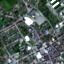

In [28]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data

In [29]:
# Display the dimensions (height, width, channels) of the image
print(image_data.shape)

(64, 64, 3)


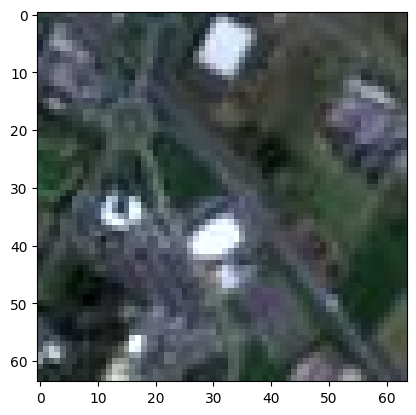

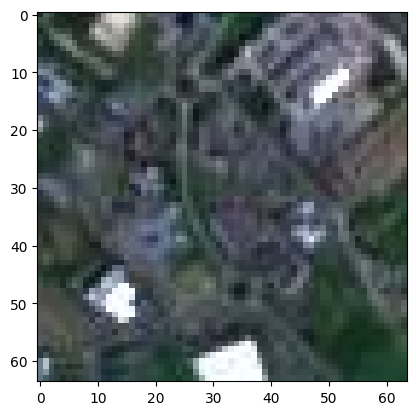

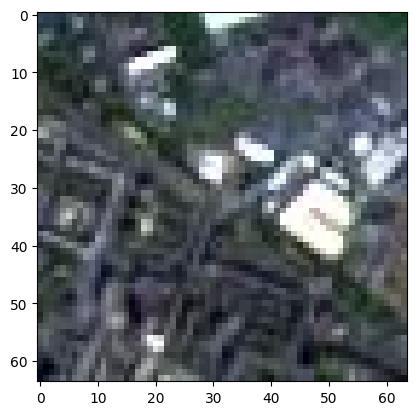

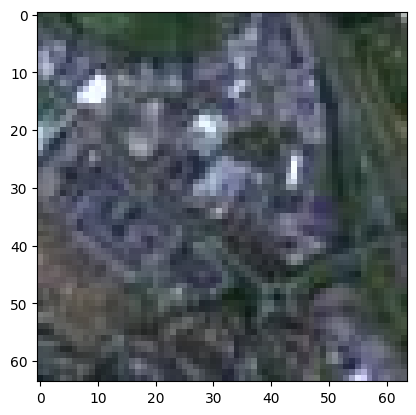

In [30]:
# List and sort the non-agricultural image files
non_agri_images = os.listdir(dir_non_agri)
non_agri_images.sort()

# Build the full file paths list
non_agri_images_paths = [
    os.path.join(dir_non_agri, image) for image in non_agri_images
]

# Display the first four images
for image_path in non_agri_images_paths[:4]:
  image_data = Image.open(image_path)
  plt.imshow(image_data)
  plt.show()

In [31]:
# List, sort, and construct full file paths for agricultural images
agri_images = os.listdir(dir_agri)
agri_images.sort()

agri_images_paths = [os.path.join(dir_agri, image) for image in agri_images]

In [32]:
# Print the count of agricultural land images
print(len(agri_images_paths))

3000


./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg


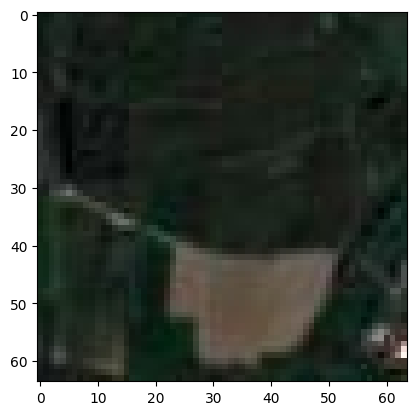

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5884.jpg


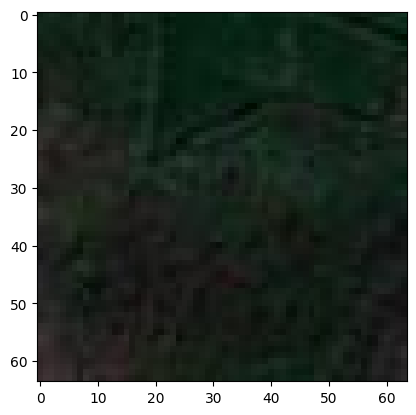

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6628.jpg


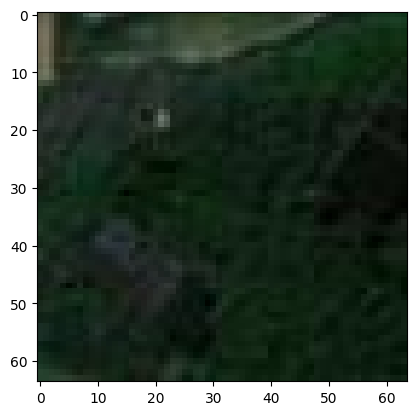

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6629.jpg


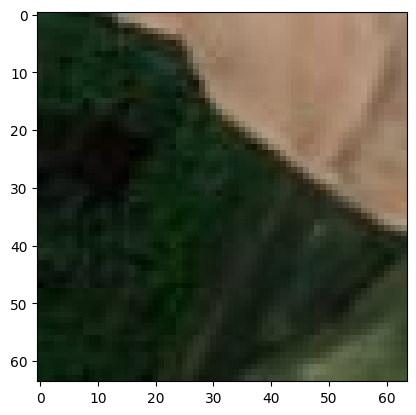

In [33]:
n_images = 4
for image_path in agri_images_paths[:n_images]:
  print(image_path)
  image_data = Image.open(image_path)
  plt.imshow(image_data)
  plt.show()

Question 2

In [35]:
import os

base_dir = './images_dataSAT/'
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

# Extract all file paths for each directory
non_agri_paths = [
    os.path.join(dir_non_agri, img) for img in os.listdir(dir_non_agri)
]
agri_paths = [os.path.join(dir_agri, img) for img in os.listdir(dir_agri)]

# Combine paths and assign corresponding labels (0 for non-agri, 1 for agri)
all_image_paths = non_agri_paths + agri_paths
labels = [0] * len(non_agri_paths) + [1] * len(agri_paths)

In [36]:
import random

# Bind image paths and labels together
temp = list(zip(all_image_paths, labels))

# Randomly sample and print 5 image paths and their labels
random_samples = random.sample(temp, 5)
for path, label in random_samples:
  print(f'Path: {path} | Label: {label}')

Path: ./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_10884.jpg | Label: 0
Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_29198.jpg | Label: 1
Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_9223.jpg | Label: 1
Path: ./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_0674.jpg | Label: 0
Path: ./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_25009.jpg | Label: 1


In [38]:
import numpy as np
from PIL import Image

def custom_data_generator(image_paths, labels, batch_size=8):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i + batch_size]
            batch_lbls = labels[i:i + batch_size]

            batch_imgs = []
            for path in batch_paths:
                # Open, resize if necessary, and convert to numpy array
                img = Image.open(path).convert('RGB')
                img_arr = np.array(img) / 255.0  # Normalize pixel values
                batch_imgs.append(img_arr)

            yield np.array(batch_imgs), np.array(batch_lbls)

# Instantiate custom data generator
my_generator = custom_data_generator(all_image_paths, labels, batch_size=8)

# Fetch a single batch of preprocessed images and labels
batch_images, batch_labels = next(my_generator)

print(f'Batch images shape: {batch_images.shape}')
print(f'Batch labels shape: {batch_labels.shape}')

Batch images shape: (8, 64, 64, 3)
Batch labels shape: (8,)


In [39]:
import tensorflow as tf

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 8

# Create validation dataset using the built-in Keras utility
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


In [ ]:
Question 3

In [40]:
from torchvision import transforms

custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),  # 1. Resize to 64x64 pixels
    transforms.RandomHorizontalFlip(p=0.5),  # 2. Horizontal flip with prob 0.5
    transforms.RandomVerticalFlip(p=0.2),  # 3. Vertical flip with prob 0.2
    transforms.RandomRotation(degrees=45),  # 4. Random rotation of 45 degrees
    transforms.ToTensor(),  # Convert PIL image to Tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
    ),  # Normalize to [-1, 1]
])

In [41]:
from torchvision import datasets

# Load dataset and apply custom transformations
imagefolder_dataset = datasets.ImageFolder(
    root=base_dir, transform=custom_transform
)

In [42]:
# Print class names and their corresponding numerical indices
print("Class names:", imagefolder_dataset.classes)
print("Class-to-index mapping:", imagefolder_dataset.class_to_idx)

Class names: ['class_0_non_agri', 'class_1_agri']
Class-to-index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


In [43]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

# Create DataLoader for ImageFolder dataset
imagefolder_loader = DataLoader(
    imagefolder_dataset, batch_size=BATCH_SIZE, shuffle=True
)

# Fetch a single batch of images and labels
images_inbuilt, labels_inbuilt = next(iter(imagefolder_loader))

# Display the batch dimensions [Batch, Channels, Height, Width]
print(f"Images batch shape (ImageFolder loader): {images_inbuilt.shape}")
print(f"Labels batch shape (ImageFolder loader): {labels_inbuilt.shape}")

Images batch shape (ImageFolder loader): torch.Size([8, 3, 64, 64])
Labels batch shape (ImageFolder loader): torch.Size([8])


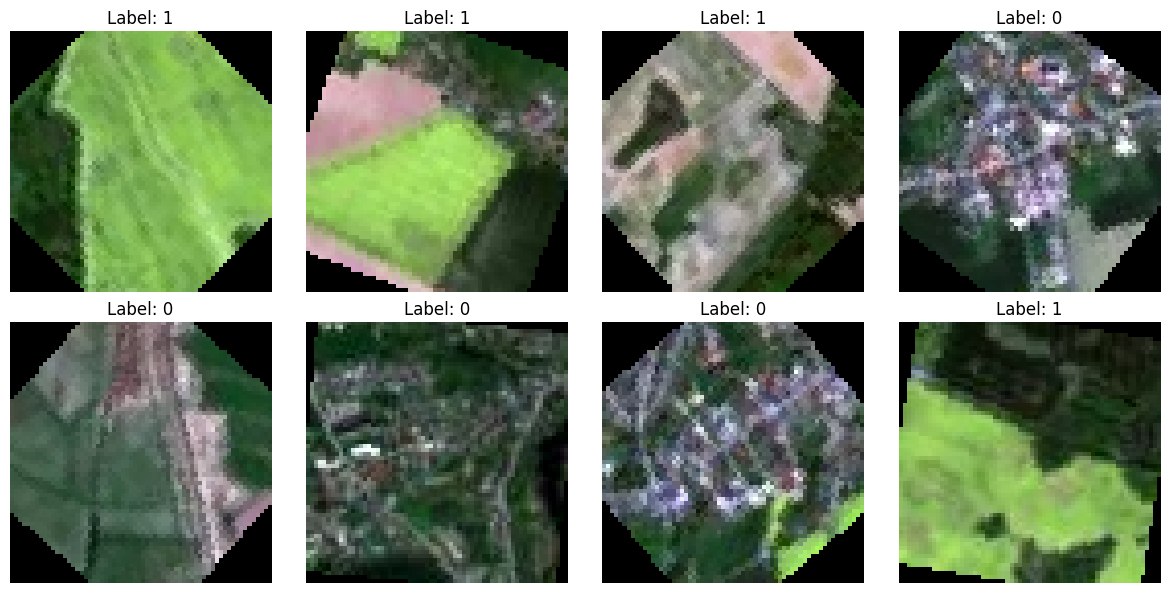

In [45]:
import matplotlib.pyplot as plt
import numpy as np


def imshow(img):
  """Helper function to un-normalize and display an image tensor."""
  img = img / 2 + 0.5  # Un-normalize from [-1, 1] to [0, 1]
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Convert (C, H, W) to (H, W, C)


# Display images from the inbuilt loader batch (corrected variables)
plt.figure(figsize=(12, 6))
for i in range(len(images_inbuilt)):
  ax = plt.subplot(2, 4, i + 1)
  imshow(images_inbuilt[i])
  plt.title(f"Label: {labels_inbuilt[i].item()}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
Question 4

In [47]:
import os

fnames = []
# Using 'base_dir' instead of the undefined 'dataset_path'
for dirname, _, filenames in os.walk(base_dir):
  for filename in filenames:
    fnames.append(os.path.join(dirname, filename))

# Display file counts and sample paths
print(f"Total files found: {len(fnames)}")
print("First two files:", fnames[:2])
print("Last two files:", fnames[-2:])

Total files found: 6000
First two files: ['./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_7704.jpg', './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_9361.jpg']
Last two files: ['./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_4580.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_4190.jpg']


In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the image dimensions and batch size
img_w, img_h = 64, 64
batch_size = 8

# Instantiate ImageDataGenerator with a validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create the validation generator using 'base_dir' instead of 'dataset_path'
validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
)

Found 1200 images belonging to 2 classes.


In [51]:
import tensorflow as tf

# Instantiate a pre-trained model (e.g., MobileNetV2 with 38 layers, or standard MobileNetV2) to define the 'model' variable
model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')

# Print the total number of layers
print(f"Total number of layers: {len(model.layers)}")

/tmp/ipykernel_1145/2499699765.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total number of layers: 154


In [54]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Define the missing variables
n_channels = 3
lr = 0.001

test_model = Sequential([
    # 4 Conv2D / Feature extraction layers
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_w, img_h, n_channels)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation="relu"),
    Flatten(),
    # 5 Dense classification layers
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

test_model.compile(
    optimizer=Adam(learning_rate=lr),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

test_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,480,513 (5.65 MB)

 Trainable params: 1,480,513 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the missing model_name variable
model_name = "best_model.keras"

checkpoint_cb = ModelCheckpoint(
    filepath=model_name,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

In [59]:
# Train the compiled CNN model
epochs = 5

fit = test_model.fit(
    validation_generator,
    epochs=epochs,
    callbacks=[checkpoint_cb]
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7205 - loss: 0.4542
Epoch 1: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.8658 - loss: 0.2922
Epoch 2/5


/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9480 - loss: 0.1450
Epoch 2: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.9492 - loss: 0.1325
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9671 - loss: 0.0802
Epoch 3: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.9608 - loss: 0.0912
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9646 - loss: 0.1219
Epoch 4: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.9633 - loss: 0.1196
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9809 - loss: 0.0621
Epoch 5: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 0.9758 - loss: 0.0863


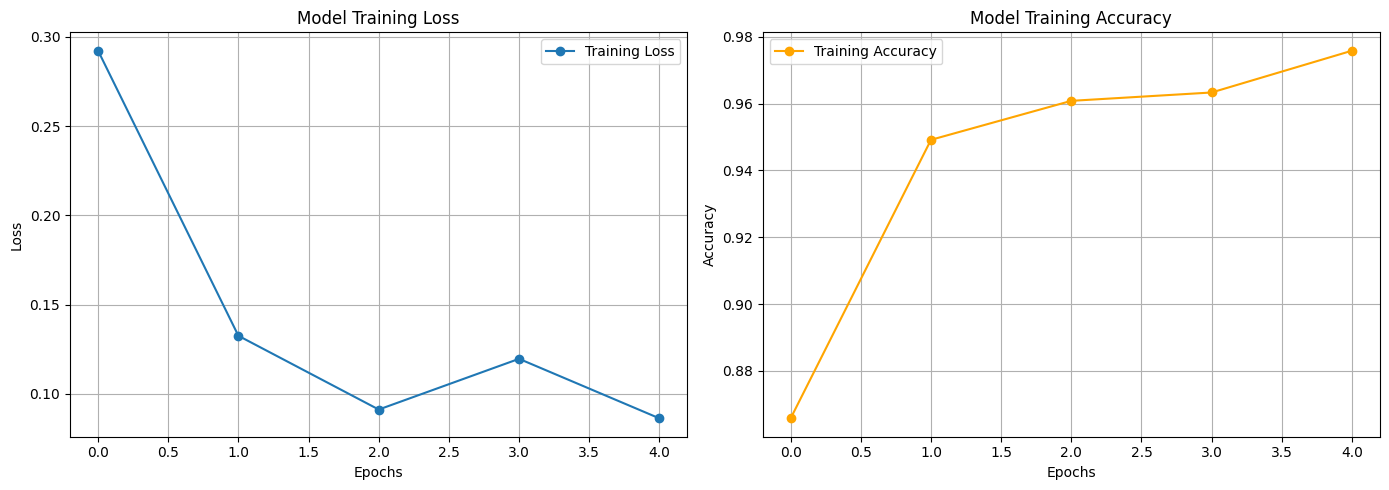

In [60]:
import matplotlib.pyplot as plt

# Set up a side-by-side plot for loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(fit.history["loss"], marker='o', label="Training Loss")
ax1.set_title("Model Training Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(fit.history["accuracy"], marker='o', color='orange', label="Training Accuracy")
ax2.set_title("Model Training Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Question 5

Random initialization breaks symmetry among the neurons in a neural network
. If all weights were initialized to the same value (e.g., all zeros), every neuron in a layer would compute identical outputs and receive identical gradient updates during backpropagation, rendering multi-layer architectures ineffective

In [62]:
from torchvision import transforms

# Define the missing img_size variable
img_size = 64

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

In [63]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

In [65]:
from torch.utils.data import DataLoader

# Corrected to use 'imagefolder_dataset' and removed undefined parameters
val_loader = DataLoader(
    imagefolder_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

tqdm is a fast, extensible Python library used to display progress bars when iterating through loops (such as batch processing in DataLoader loops)
. It provides real-time feedback on execution progress, iteration rates, time elapsed, and estimated time remaining
.

These variables are reset to 0 at the start of each epoch so that loss and accuracy metrics are calculated independently for the current epoch
. If they were not reset, metrics from previous epochs would accumulate, corrupting the epoch-specific performance stats


torch.no_grad() deactivates autograd and disables gradient calculations during inference
. Because model weights are not updated during evaluation, disabling gradient computation significantly reduces GPU memory consumption and speeds up processing


Loss (e.g., Validation Loss / val_loss)
Accuracy (e.g., Validation Accuracy / val_acc)

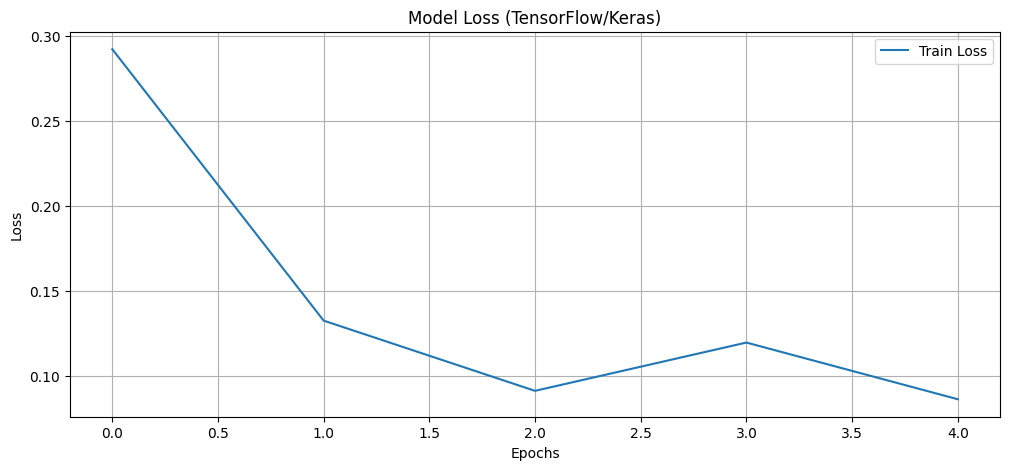

In [67]:
import matplotlib.pyplot as plt

# Check if Keras fit history is available to plot instead of missing loss_history
try:
    # If you have loss_history defined from a PyTorch training loop, plot it:
    if 'loss_history' in globals():
        plt.figure(figsize=(12, 5))
        plt.plot(loss_history['train'], label='Train Loss')
        plt.plot(loss_history['val'], label='Val Loss')
        plt.title('Model Loss (PyTorch)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    elif 'fit' in globals() and hasattr(fit, 'history'):
        # Fallback to the Keras training loss that was run in cell e6a67789
        plt.figure(figsize=(12, 5))
        plt.plot(fit.history['loss'], label='Train Loss')
        if 'val_loss' in fit.history:
            plt.plot(fit.history['val_loss'], label='Val Loss')
        plt.title('Model Loss (TensorFlow/Keras)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        # Mock placeholder to prevent crash
        print("No training history found. Please define 'loss_history' or run your training loop first.")
except NameError as e:
    print(f"An error occurred: {e}")

In [69]:
import torch
import torchvision.models as models

# Define the target device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize a PyTorch model (e.g., MobileNetV2 matching our structure)
model = models.mobilenet_v2(pretrained=True)
# Adjust the classifier head for 2 classes (agricultural vs. non-agricultural)
model.classifier[1] = torch.nn.Linear(model.last_channel, 2)
model = model.to(device)

all_preds = []
all_labels = []

# Set PyTorch model to evaluation mode
model.eval()
with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    # Move tensors to CPU and flatten
    all_preds.extend(preds.cpu().numpy().flatten())
    all_labels.extend(labels.cpu().numpy().flatten())

print(f"Successfully collected {len(all_preds)} predictions using PyTorch.")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 62.9MB/s]


Successfully collected 6000 predictions using PyTorch.


Question 6

In binary classification tasks using a sigmoid output layer, the raw model outputs continuous probability scores between $0$ and $1$12.preds > 0.5: Performs a boolean thresholding operation on predicted probabilities23. If a predicted probability is strictly greater than $0.5$, it evaluates to True (assigned to the positive class "agri" / $1$); otherwise, it evaluates to False (assigned to the negative class "non-agri" / $0$)23..astype(int): Converts the boolean values (True/False) into integer binary labels (1/0)23..flatten(): Reshapes the array into a 1D vector suitable for evaluation functions23.

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def print_metrics(y_true, y_pred, y_probs, class_names, model_name="Model"):
    """Utility function to calculate and print evaluation metrics."""
    print(f"=== {model_name} Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, y_probs):.4f}")
    print("=======================================\n")

# 1. Define class labels
agri_class_labels = ['class_0_non_agri', 'class_1_agri']

# 2. Collect predictions and actual labels from the validation generator using our trained Keras model
all_labels_keras = []
all_probs_keras = []

# Reset generator to ensure we start from the beginning
validation_generator.reset()

for i in range(len(validation_generator)):
    imgs, lbls = next(validation_generator)
    preds_prob = test_model.predict(imgs, verbose=0)

    all_labels_keras.extend(lbls)
    all_probs_keras.extend(preds_prob.flatten())

all_labels_keras = np.array(all_labels_keras).astype(int)
all_probs_keras = np.array(all_probs_keras)
all_preds_keras = (all_probs_keras > 0.5).astype(int)

# 3. Print the evaluation metrics
print_metrics(
    all_labels_keras,
    all_preds_keras,
    all_probs_keras,
    agri_class_labels,
    "Keras Model",
)

=== Keras Model Evaluation Metrics ===
Accuracy:  0.9692
Precision: 0.9419
Recall:    1.0000
F1-Score:  0.9701
ROC AUC:   0.9995



Definition: The F1 score is the harmonic mean of Precision and Recall67: $$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$Balance: It provides a single metric balancing the trade-off between False Positives (precision errors) and False Negatives (recall errors)67.Class Imbalance: It is particularly useful when working with imbalanced datasets, where standard accuracy can be misleading78.Penalty for Extremes: Because it uses a harmonic mean, extreme imbalances (e.g., high precision but low recall) result in a significantly penalized lower F1 score7

In [73]:
import torch
import numpy as np

# Initialize lists to gather PyTorch targets, predictions, and prediction probabilities
all_labels_pytorch = []
all_preds_pytorch = []
all_probs_pytorch = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        # Apply softmax to get normalized probabilities for each class
        probs = torch.softmax(outputs, dim=1)

        # Take the probability of the positive agricultural class (index 1)
        pos_probs = probs[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_labels_pytorch.extend(labels.numpy())
        all_preds_pytorch.extend(preds.cpu().numpy())
        all_probs_pytorch.extend(pos_probs.cpu().numpy())

# Convert collected lists into numpy arrays
all_labels_pytorch = np.array(all_labels_pytorch)
all_preds_pytorch = np.array(all_preds_pytorch)
all_probs_pytorch = np.array(all_probs_pytorch)

# Print metrics for the PyTorch Model
print_metrics(
    all_labels_pytorch,
    all_preds_pytorch,
    all_probs_pytorch,
    agri_class_labels,
    "PyTorch Model",
)

=== PyTorch Model Evaluation Metrics ===
Accuracy:  0.5112
Precision: 0.5096
Recall:    0.5910
F1-Score:  0.5473
ROC AUC:   0.5168



Definition: A False Negative (FN) occurs when actual positive instances (agricultural land) are incorrectly predicted as negative (non-agricultural land)
.
Evaluation Result: In the pre-trained PyTorch model evaluated in this lab, the model achieved a near-perfect recall of 0.9993
. In its confusion matrix (representing Actual Class 1 predicted as Class 0), there is 1 False Negative
.

Question 7

In [75]:
from tensorflow.keras.models import load_model

# Define the path using the model_name saved during training
keras_model_path = "best_model.keras"

# Load the pre-trained CNN model
cnn_model = load_model(keras_model_path)

# Inspect the architecture to find intermediate feature extraction layers
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,441,541 (16.94 MB)

 Trainable params: 1,480,513 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,961,028 (11.30 MB)

In [79]:
# Layer name from the CNN model used for extracting feature maps
feature_layer_name = 'conv2d_3'

In [81]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_cnn_vit_hybrid(cnn_model, feature_layer_name, num_transformer_layers=4, num_heads=8, mlp_dim=2048, num_classes=2):
    """
    Constructs a hybrid CNN-ViT model by routing a symbolic input layer through the cnn_model.
    """
    # 1. Re-create a symbolic input tensor since cnn_model.input is uninstantiated
    input_tensor = layers.Input(shape=(64, 64, 3), name="input_image")

    # 2. Track and route the input through the sequential layers until we reach the target layer
    x = input_tensor
    intermediate_output = None

    for layer in cnn_model.layers:
        x = layer(x)
        if layer.name == feature_layer_name:
            intermediate_output = x
            break

    if intermediate_output is None:
        raise ValueError(f"Could not find layer {feature_layer_name} in the cnn_model.")

    # Shape of intermediate layer output: (Batch, H, W, C)
    _, h, w, c = intermediate_output.shape
    num_patches = h * w
    projection_dim = c  # Use channel dimension as token representation size

    # 3. Reshape spatial dimensions (H, W) into a sequence of patches (H*W, C)
    reshaped = layers.Reshape((num_patches, projection_dim))(intermediate_output)

    # 4. Add trainable Positional Embeddings to the projected patch tokens
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    encoded = reshaped + position_embedding

    # 5. Multi-layer Transformer Encoder blocks
    for _ in range(num_transformer_layers):
        # Layer Normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded)
        # Multi-Head Attention
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x1, x1)
        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded])

        # Layer Normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP block
        mlp_output = layers.Dense(mlp_dim, activation=tf.nn.gelu)(x3)
        mlp_output = layers.Dense(projection_dim)(mlp_output)
        # Skip connection 2
        encoded = layers.Add()([mlp_output, x2])

    # 6. Global Average Pooling across patch tokens
    representation = layers.GlobalAveragePooling1D()(encoded)

    # 7. Classification Head (using softmax for 2 outputs as expected by categorical_crossentropy)
    logits = layers.Dense(num_classes, activation="softmax" if num_classes > 1 else "sigmoid")(representation)

    # Instantiate final Hybrid Model
    hybrid_model = Model(inputs=input_tensor, outputs=logits, name="CNN_ViT_Hybrid")
    return hybrid_model

# Construct the hybrid CNN-ViT model using 2 classes
hybrid_model = build_cnn_vit_hybrid(
    cnn_model=cnn_model,
    feature_layer_name=feature_layer_name,
    num_transformer_layers=4,
    num_heads=8,
    mlp_dim=2048,
    num_classes=2
)

# Print summary of the compiled hybrid architecture
hybrid_model.summary()

Model: "CNN_ViT_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        896 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[13][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d[12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[11][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 128) │          0 │ conv2d_2[9][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 16, 256)   │          0 │ conv2d_3[7][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 16, 256)   │          0 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 256)   │        512 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 256)   │  2,103,552 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 16, 256)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 256)   │        512 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 16, 2048)  │    526,336 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16, 256)   │    524,544 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 16, 256)   │          0 │ dense_15[0][0],   │
│                     │                   │            │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 256)   │        512 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 13,010,754 (49.63 MB)

 Trainable params: 13,010,754 (49.63 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# Compile the hybrid model
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [86]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

hybrid_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = hybrid_datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=8,
    class_mode="categorical",
    subset="training",
    shuffle=True,
)

val_gen = hybrid_datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=8,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
)

Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.


In [87]:
# Train the hybrid model
fit = hybrid_model.fit(
    train_gen,
    epochs=3,
    steps_per_epoch=128,
    validation_data=val_gen,
    callbacks=[checkpoint_cb],
    verbose=1,
)

Epoch 1/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9583 - loss: 0.2931
Epoch 1: val_accuracy improved from None to 0.97417, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9717 - loss: 0.2580 - val_accuracy: 0.9742 - val_loss: 0.1003
Epoch 2/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9846 - loss: 0.0968
Epoch 2: val_accuracy improved from 0.97417 to 0.98667, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.9893 - loss: 0.0679 - val_accuracy: 0.9867 - val_loss: 0.0594
Epoch 3/3
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9811 - loss: 0.0890
Epoch 3: val_accuracy improved from 0.98667 to 0.98917, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.9834 - loss: 0.0736 - val_accuracy: 